# Data vs MC — final selection, per-TPC, beam-quality data

Overlaid histograms for **fully selected, per-TPC contained** events.

- **Data**: `evt_good` from `beam_data_1e20_qualitycut.df` (`beam_quality.ipynb`)
- **MC**: `dfs_from_dir` on `sel_mup-wgts_mcstat/merged_perTPC`
- **Intime cosmics**: `dfs_from_dir` on `sel_mup-mc-Intime/merged_perTPC` (also loads OffBeamLight for reference)
- **Plotting**: `overlay_hists` (topology + GENIE sideband breakdowns), same as `compare_FVs.ipynb`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [6]:
# --- paths ---
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
QUALITY_DF_DIR = path.join(DFS_ROOT, "2026_05_16_230705__sel_mup-data-1e20/merged_perTPC")
QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")

DIR_MC = path.join(DFS_ROOT, "2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_11_083624__sel_mup-mc-Intime/merged_perTPC")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(
    save_fig_base_dir,
    f"data_mc_comparison_{today_str}",
)
if save_fig and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
print("quality-cut df:", QUALITY_DF_PATH)
print("saving plots in", save_fig_dir)

quality-cut df: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/beam_data_1e20_qualitycut.df
saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_comparison_20260518


## Load MC, intime MC, and OffBeamLight (`dfs_from_dir`)

In [7]:
from pyanalib.split_df_helpers_new import dfs_from_dir

mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_mup-wgts_mcstat",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
intime_dfs = dfs_from_dir(
    DIR_INTIME,
    filename_str="sel_mup-mc-Intime",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
offbeam_dfs = dfs_from_dir(
    DIR_OFFBEAM,
    filename_str="sel_mup-data-OffBeamLight",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]
intime_evt_df = intime_dfs["evt"]
intime_hdr_df = intime_dfs["hdr"]
offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

print(f"mc:      evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}")
print(f"intime:  evt={len(intime_evt_df):,}  hdr={len(intime_hdr_df):,}")
print(f"offbeam: evt={len(offbeam_evt_df):,}  hdr={len(offbeam_hdr_df):,}")

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

Found 2 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC/2026_05_11_084007__sel_mup-wgts_mcstat_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC/2026_05_11_084007__sel_mup-wgts_mcstat_merged_0001.df']


100%|██████████| 2/2 [00:23<00:00, 11.57s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_083624__sel_mup-mc-Intime/merged_perTPC/2026_05_11_083624__sel_mup-mc-Intime_merged_0000.df']


100%|██████████| 1/1 [00:03<00:00,  3.60s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC/2026_05_11_040015__sel_mup-data-OffBeamLight_merged_0000.df']


100%|██████████| 1/1 [00:04<00:00,  4.49s/it]

REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc:      evt=54,287  hdr=4,687,743
intime:  evt=96  hdr=1,917,363
offbeam: evt=62  hdr=1,655,098



/tmp/ipykernel_2917617/1377901973.py:33: PerformanceWarning: indexing past lexsort depth may impact performance.
  mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999


## Load beam-quality-filtered data

In [8]:
quality_dfs = load_dfs(
    QUALITY_DF_PATH,
    keys2load=["hdr", "trigger", "evt_good"],
    n_max_concat=1,
)
data_evt_df = quality_dfs["evt_good"]
data_hdr_df = quality_dfs["hdr"].join(quality_dfs["trigger"])

data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")

evt_good rows: 12,804


/tmp/ipykernel_2917617/2331643992.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df[("mc", "iscc")] = 999


In [16]:
data_tot_pot = data_hdr_df["pot"].sum() * 0.98

In [23]:
pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print(f"mc_pot_scale: {mc_pot_scale:.3e}")
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

intime_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.0753
scale_intime_to_lightdata = (1 - f) * data_gates / intime_gates
print(f"intime data scale: {scale_intime_to_lightdata:.2f}")
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

mc_pot_scale: 2.125e-01
intime data scale: 0.22


## Per-TPC contained cut (MC / intime)

Data `evt_good` is already from `merged_perTPC` (full selection + per-TPC). Apply the same
containment cut to MC and intime MC (`dfs_from_dir` prints a reminder to recheck FV / TKI).

In [24]:
perTPC_inset = 10

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df = mc_evt_df.loc[perTPC_cut(mc_evt_df)]
intime_evt_df = intime_evt_df.loc[perTPC_cut(intime_evt_df)]

print(f"perTPC: data={len(data_evt_df):,} mc={len(mc_evt_df):,} intime={len(intime_evt_df):,}")

perTPC: data=12,804 mc=54,287 intime=96


In [25]:
for df in (mc_evt_df, data_evt_df, intime_evt_df):
    df[("mu", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("mu", "pfp", "trk", "dir", "x", "", "")],
            df[("mu", "pfp", "trk", "dir", "y", "", "")],
        )
    )
    df[("p", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("p", "pfp", "trk", "dir", "x", "", "")],
            df[("p", "pfp", "trk", "dir", "y", "", "")],
        )
    )

/tmp/ipykernel_2917617/958366433.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("mu", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_2917617/958366433.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("p", "pfp", "trk", "phi", "", "", "")] = np.degrees(


In [31]:
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)
data_evt_df, n_evt_before_fv = evt_df_fixed(data_evt_df)
intime_evt_df, n_evt_before_fv = evt_df_fixed(intime_evt_df)
offbeam_evt_df, n_evt_before_fv = evt_df_fixed(offbeam_evt_df)

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_2917617/2647123303.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
/tmp/ipykernel_2917617/2647123303.py:27: PerformanceWarning: indexing past lexsort depth may impact performance.
  df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']


In [26]:
import pickle

def get_syst_unc(var_config):
    date_str = "20260220"
    mcstat_syst = np.load(
        f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/mcstat_syst_dict.npz",
        allow_pickle=True,
    )
    mcstat_syst = dict(mcstat_syst)[var_config.var_save_name].item()["MCstat"]["cov_frac"]

    g4_syst = np.load(
        f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/g4_syst_dict.npz",
        allow_pickle=True,
    )
    g4_syst = dict(g4_syst)[var_config.var_save_name].item()["G4"]["cov_frac"]

    flux_syst = np.load(
        f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/flux_syst_dict.npz",
        allow_pickle=True,
    )
    flux_syst = dict(flux_syst)[var_config.var_save_name].item()["flux"]["cov_frac"]

    date_str = "20260222"
    cosmics_syst = np.load(
        f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/cosmics_syst_dict.npz",
        allow_pickle=True,
    )
    cosmics_syst = dict(cosmics_syst)[var_config.var_save_name].item()["Cosmics"]["cov_frac"]

    date_str = "20260219"
    genie_syst = pickle.load(
        open(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cov_mat_dict-{date_str}.pkl", "rb")
    )
    genie_syst = genie_syst[var_config.var_save_name]["genie"]

    pot_frac_unc = 0.02
    ntargets_frac_unc = 0.01

    frac_uncert_total = np.zeros(len(var_config.bin_centers))
    cov_total = np.zeros((len(var_config.bin_centers), len(var_config.bin_centers)))
    for syst in (mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst):
        cov_total += syst
        frac_uncert_total += np.diag(syst) ** 2
    for syst in (pot_frac_unc, ntargets_frac_unc):
        cov_total += np.diag(syst * np.ones(len(var_config.bin_centers)) ** 2)
        frac_uncert_total += (syst * np.ones(len(var_config.bin_centers))) ** 2
    frac_uncert_total = np.sqrt(frac_uncert_total)
    return cov_total, frac_uncert_total

In [27]:
ratio = True
approval = "internal"
textloc = [0.03, 0.55]
ax_ylim_ratio = 1.9

data_vs_mc_plotter = partial(
    overlay_hists,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=intime_evt_df,
    dirt_df=None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig,
)

## Overlay histograms

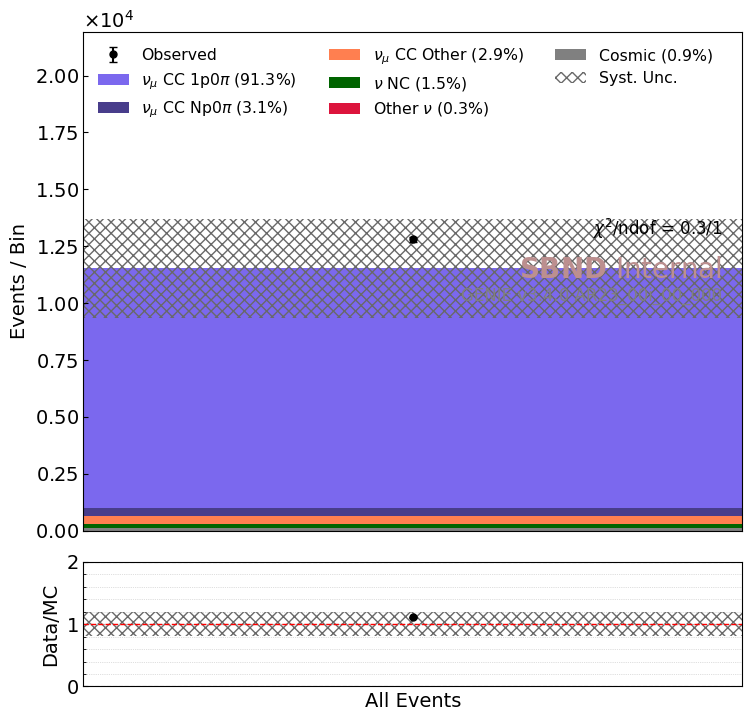

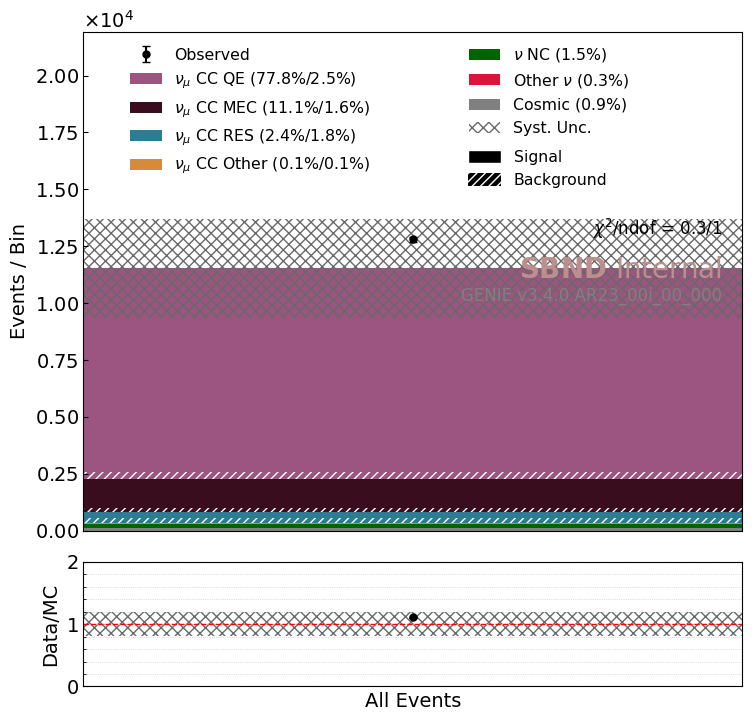

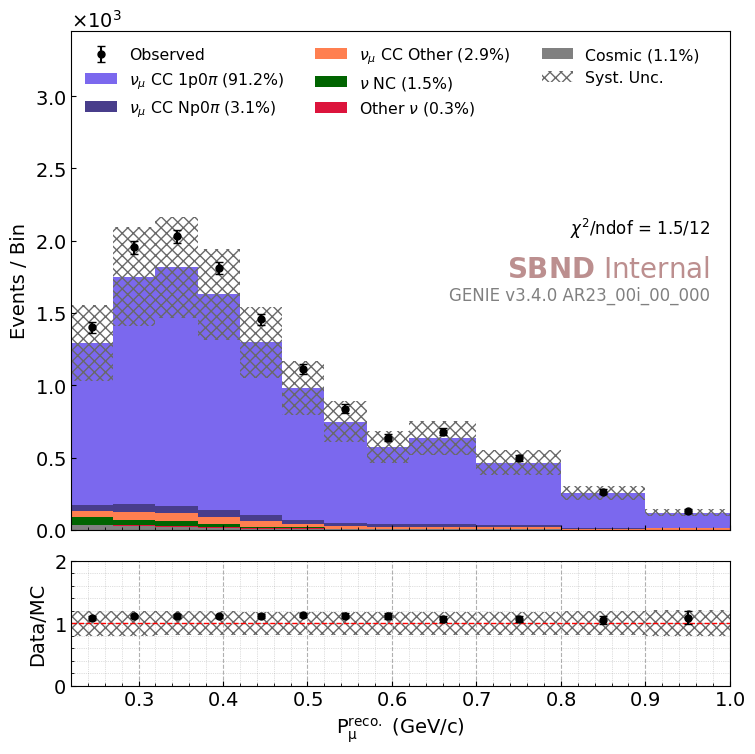

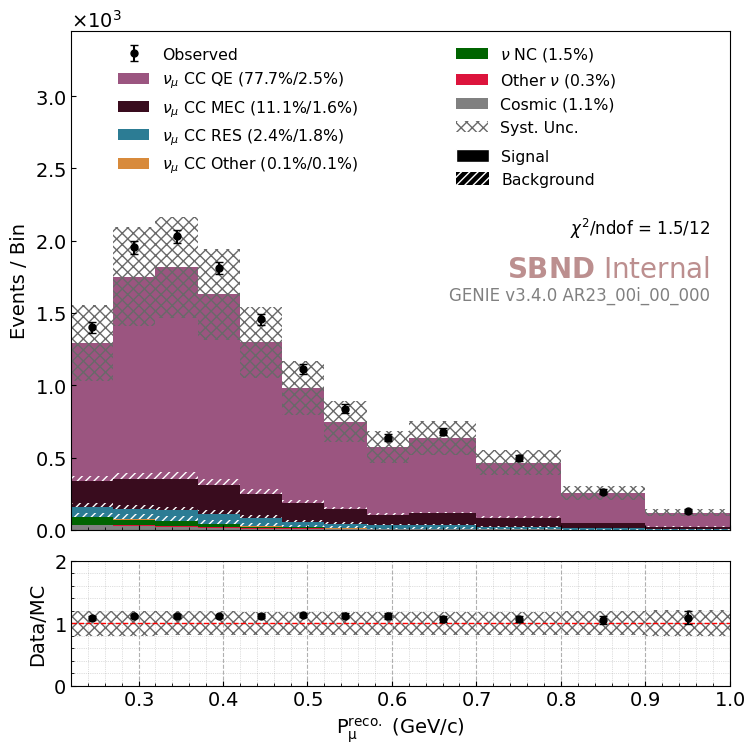

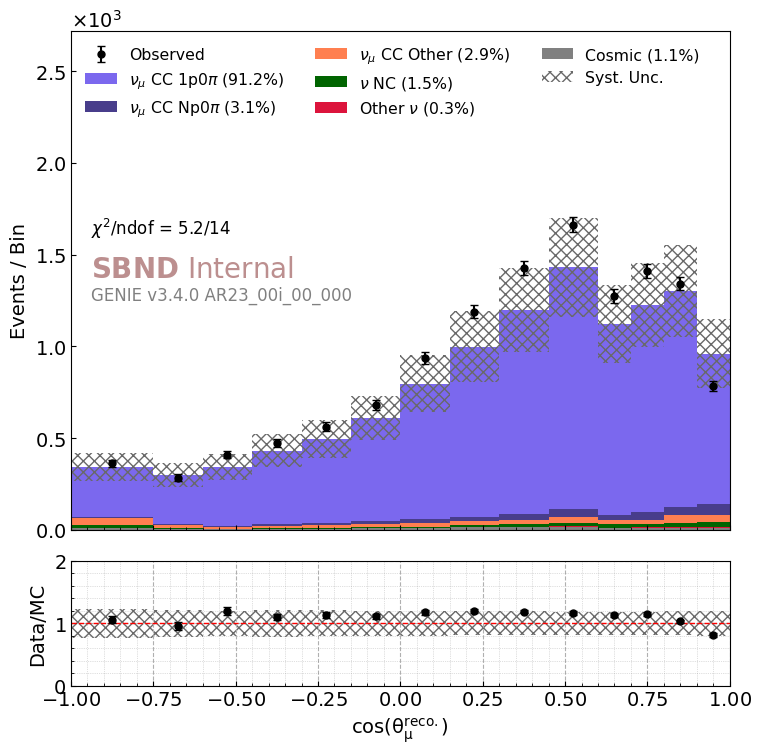

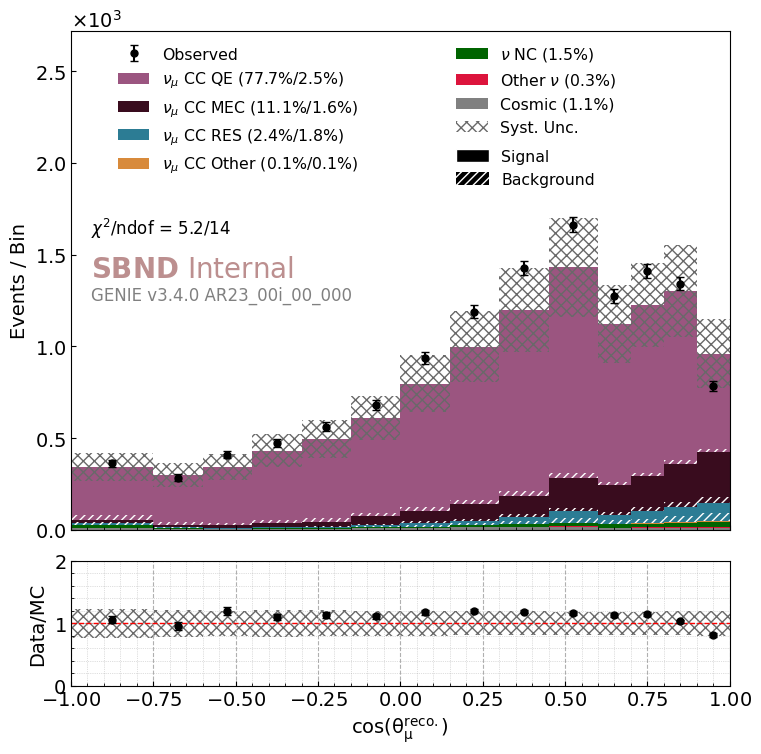

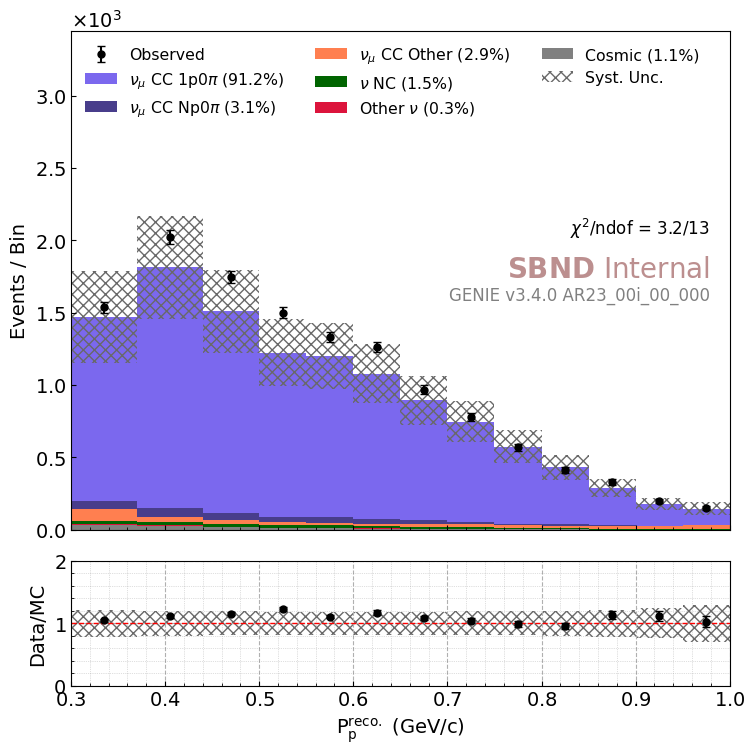

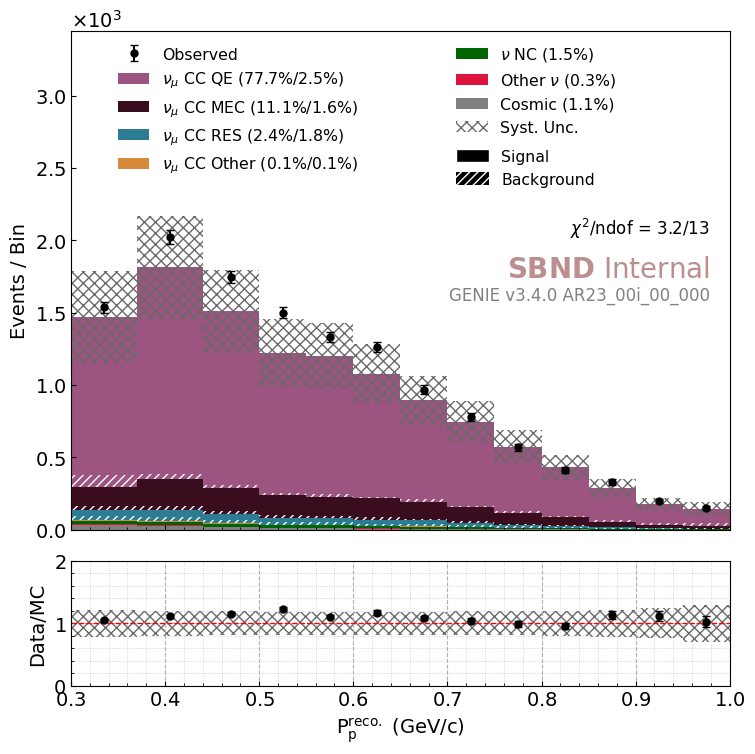

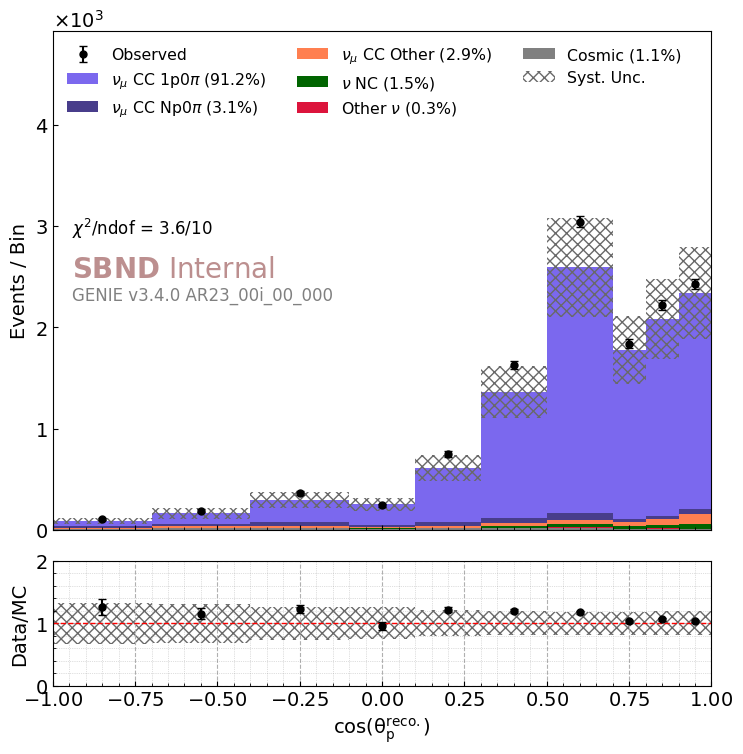

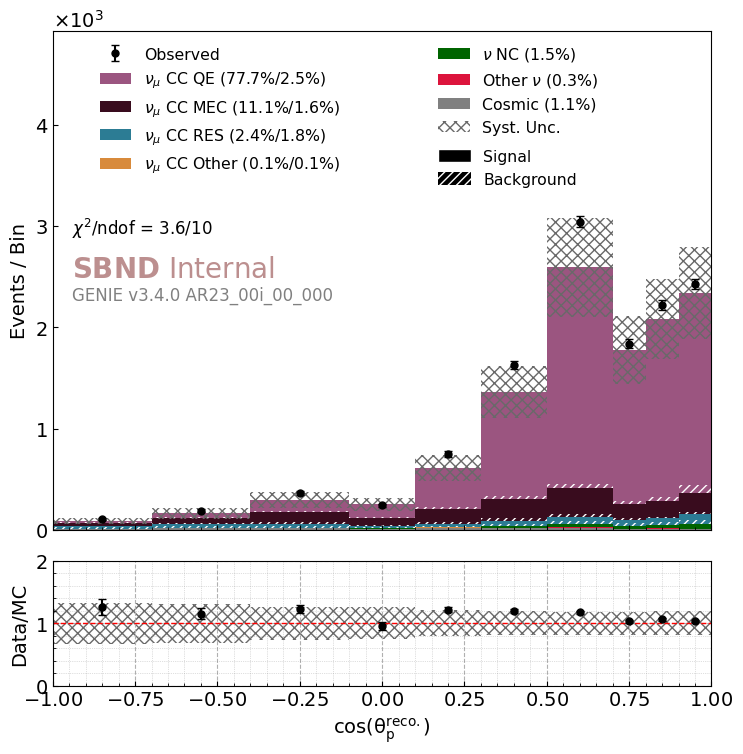

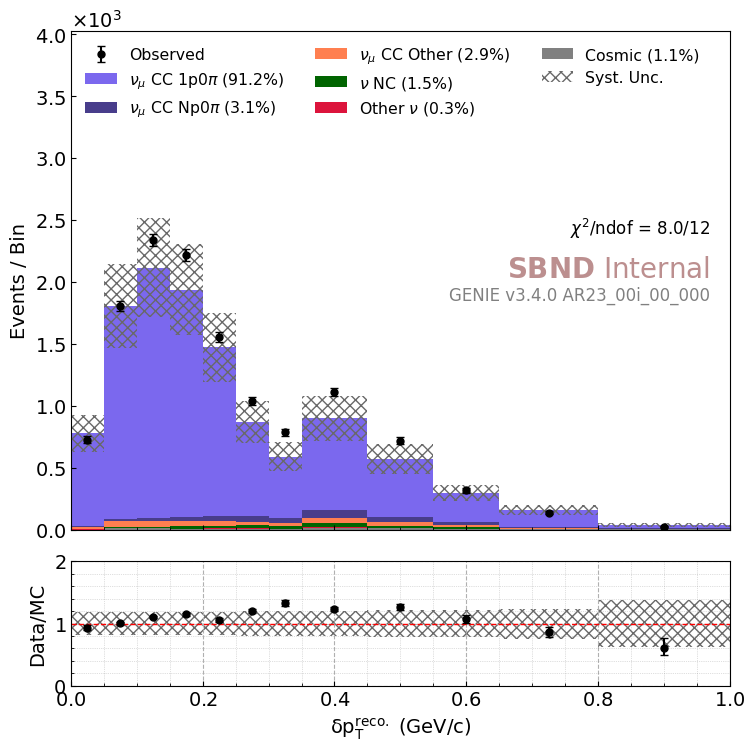

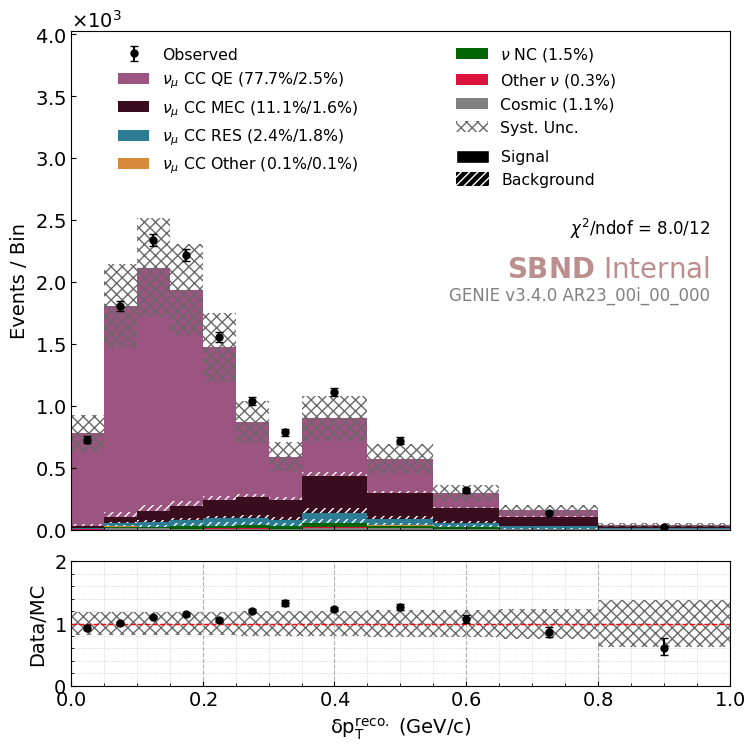

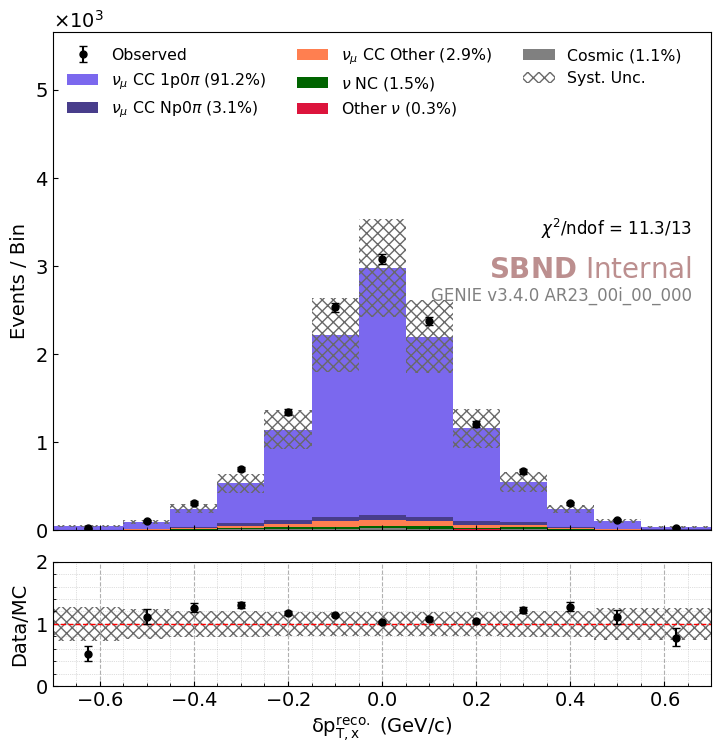

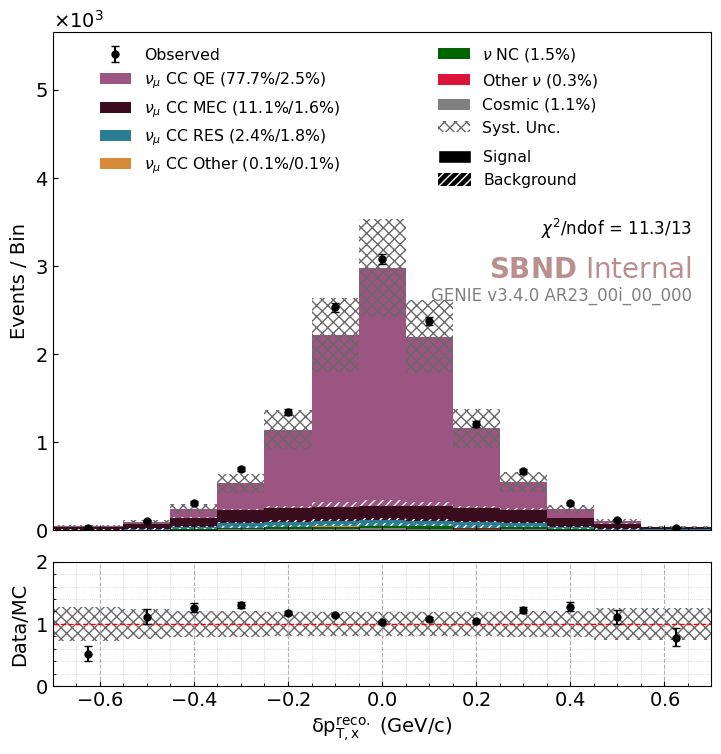

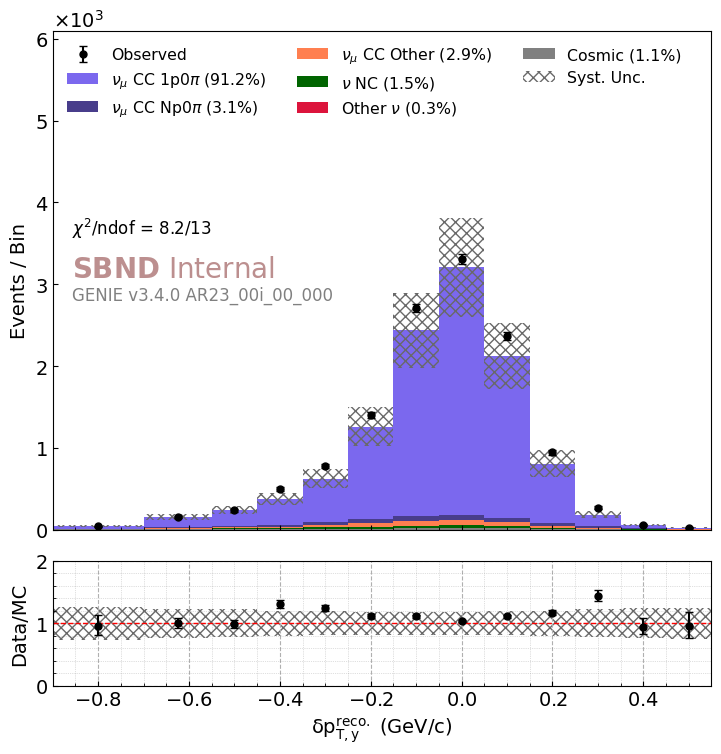

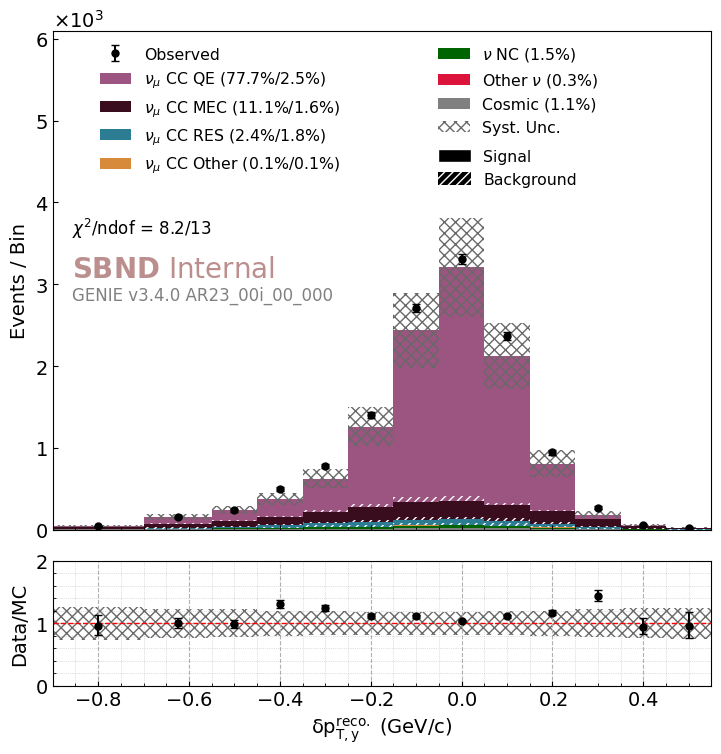

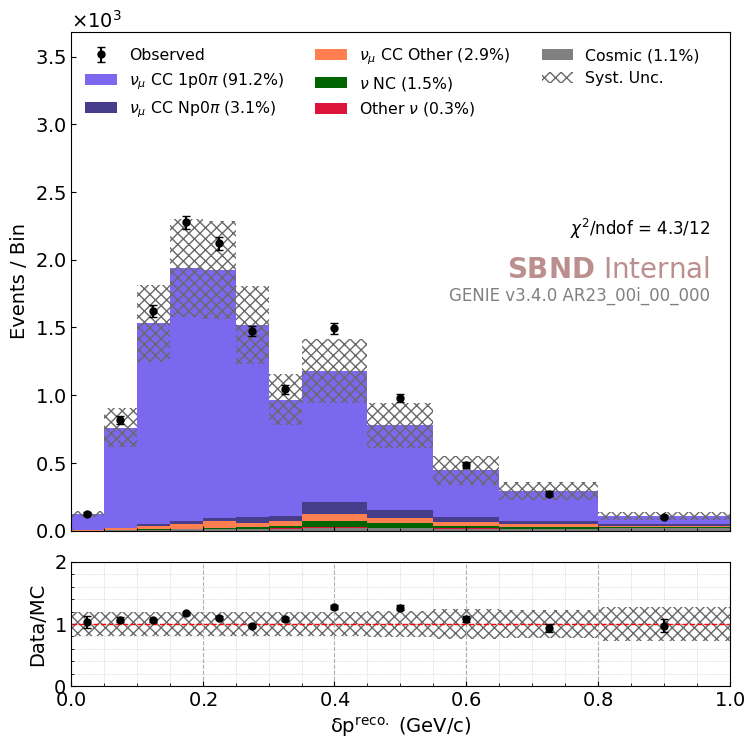

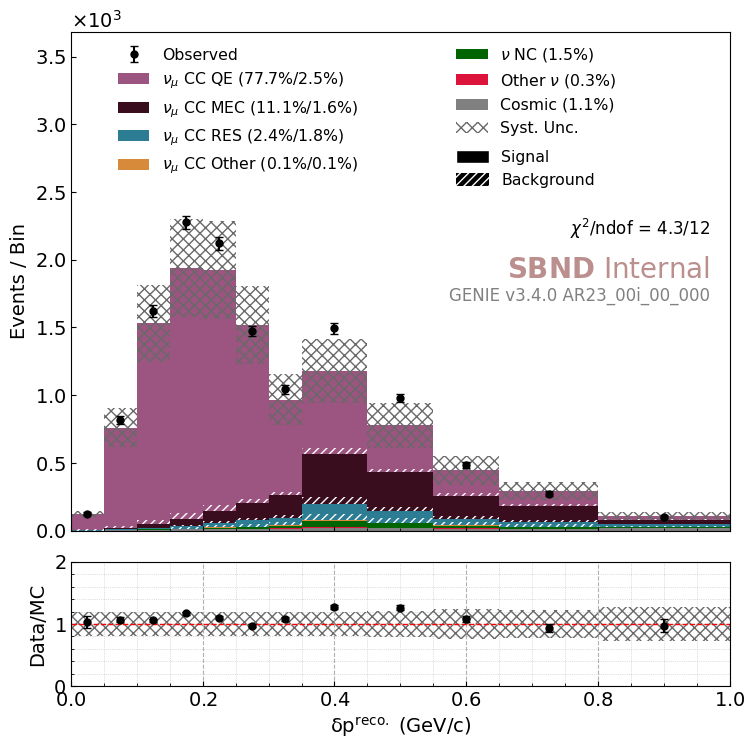

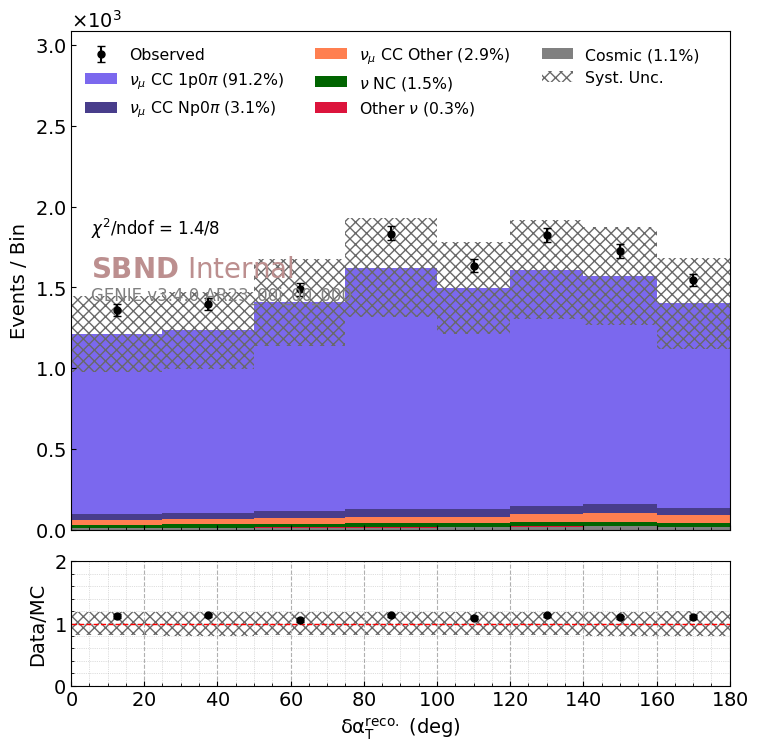

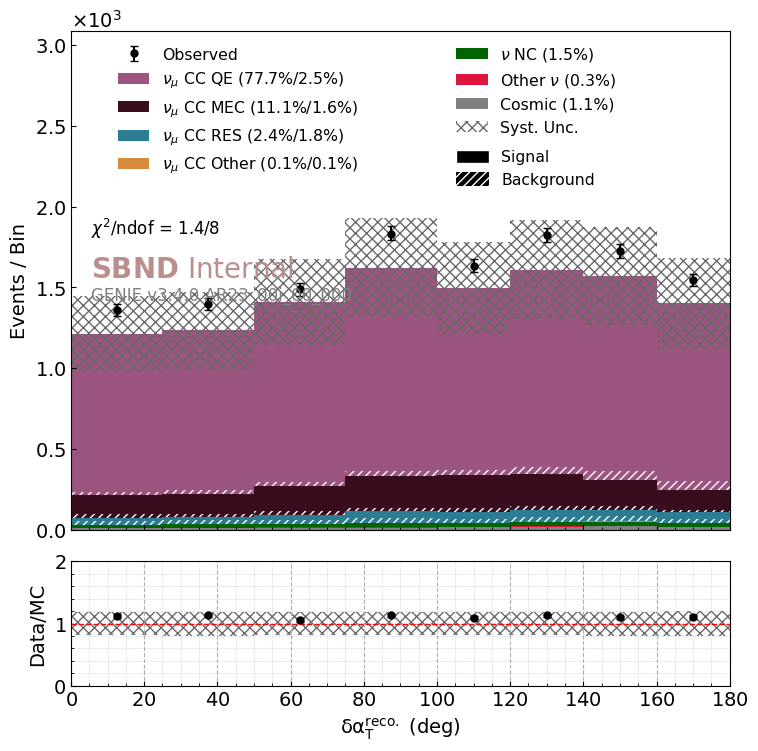

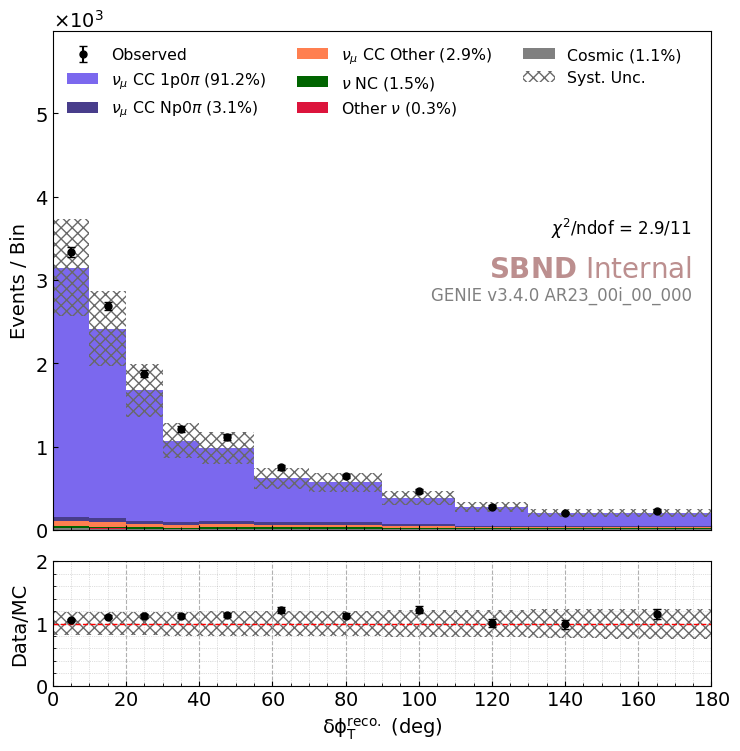

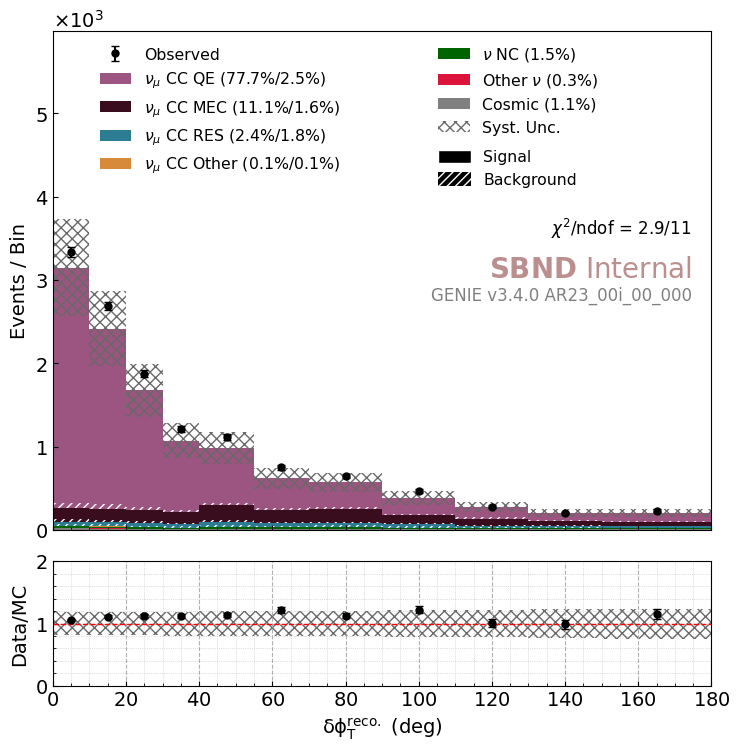

In [34]:
var_configs = [
    VariableConfig.all_events(),
    VariableConfig.muon_momentum(),
    VariableConfig.muon_direction(),
    VariableConfig.proton_momentum(),
    VariableConfig.proton_direction(),
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_Tp_x(),
    VariableConfig.tki_del_Tp_y(),
    VariableConfig.tki_del_p(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
]

for var_config in var_configs:
    cov, _ = get_syst_unc(var_config)
    for breakdown_type in ["topology", "genie_sb"]:
        plot_labels_hist = [var_config.var_labels[1], "Events / Bin", ""]
        ret = data_vs_mc_plotter(
            breakdown_type=breakdown_type,
            var_config=var_config,
            plot_labels=plot_labels_hist,
            syst=cov,
            textchi2=True,
            save_name=path.join(
                save_fig_dir,
                f"{var_config.var_save_name}_{breakdown_type}",
            ),
        )